# 🛒 Brazilian E-Commerce (Olist) Customer Analytics
---
**Author:** Rkhkumara  
**Dataset:** [Olist E-Commerce Public Dataset](https://www.kaggle.com/datasets/olistbr/brazilian-ecommerce) 100k+ transaksi nyata (2016–2018)  
**Tools:** Python (Pandas, Matplotlib, Seaborn) · SQL (SQLite)

---

## 🎯 Tujuan Analisis

Platform e-commerce seperti Olist sering terjebak dalam siklus yang tidak sehat: terus mengakuisisi pelanggan baru tanpa memahami mengapa pelanggan lama tidak kembali. Analisis ini dirancang untuk menjawab dua pertanyaan bisnis utama:

1. **Seberapa parah masalah retensi Olist?** (Cohort Retention Analysis)
2. **Siapa saja pelanggan yang paling bernilai dan apa yang harus dilakukan terhadap masing-masing segmen?** (RFM Segmentation)

Output akhirnya bukan sekadar angka, melainkan rekomendasi aksi yang bisa langsung dieksekusi oleh tim Marketing dan Product.

---

## 📂 Alur Analisis

```
1. Data Loading & Merging
2. Data Cleaning
3. Cohort Retention Analysis  →  Heatmap M0–M12
4. RFM Segmentation           →  Scoring + Visualisasi
5. Business Recommendation
```

---
## 1. Data Loading & Merging

Kita bekerja dengan tiga tabel utama dari dataset Olist:
- `olist_customers_dataset.csv` — identitas dan lokasi pelanggan
- `olist_orders_dataset.csv` — data transaksi dengan status dan timestamp
- `olist_order_items_dataset.csv` — detail item per order, termasuk harga

Ketiga tabel ini digabungkan berdasarkan `customer_id` untuk membentuk satu dataset terpadu.

In [46]:
import pandas as pd

# Membaca 3 tabel utama
customers = pd.read_csv('olist_customers_dataset.csv')
orders = pd.read_csv('olist_orders_dataset.csv')
order_items = pd.read_csv('olist_order_items_dataset.csv')

print("--- DATA CUSTOMERS ---")
print(customers.info())
print("\n--- DATA ORDERS ---")
print(orders.info())

--- DATA CUSTOMERS ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 99441 entries, 0 to 99440
Data columns (total 5 columns):
 #   Column                    Non-Null Count  Dtype 
---  ------                    --------------  ----- 
 0   customer_id               99441 non-null  object
 1   customer_unique_id        99441 non-null  object
 2   customer_zip_code_prefix  99441 non-null  int64 
 3   customer_city             99441 non-null  object
 4   customer_state            99441 non-null  object
dtypes: int64(1), object(4)
memory usage: 3.8+ MB
None

--- DATA ORDERS ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 99441 entries, 0 to 99440
Data columns (total 8 columns):
 #   Column                         Non-Null Count  Dtype 
---  ------                         --------------  ----- 
 0   order_id                       99441 non-null  object
 1   customer_id                    99441 non-null  object
 2   order_status                   99441 non-null  object
 3   order_p

In [47]:
# Menggabungkan tabel orders dan customers berdasarkan customer_id
orders_complete = pd.merge(orders, customers, on='customer_id', how='inner')

print(orders_complete[['customer_unique_id', 'order_id', 'order_purchase_timestamp', 'order_status']].head())
print("\n--- INFO DATASET BARU ---")
print(orders_complete.info())

                 customer_unique_id                          order_id  \
0  7c396fd4830fd04220f754e42b4e5bff  e481f51cbdc54678b7cc49136f2d6af7   
1  af07308b275d755c9edb36a90c618231  53cdb2fc8bc7dce0b6741e2150273451   
2  3a653a41f6f9fc3d2a113cf8398680e8  47770eb9100c2d0c44946d9cf07ec65d   
3  7c142cf63193a1473d2e66489a9ae977  949d5b44dbf5de918fe9c16f97b45f8a   
4  72632f0f9dd73dfee390c9b22eb56dd6  ad21c59c0840e6cb83a9ceb5573f8159   

  order_purchase_timestamp order_status  
0      2017-10-02 10:56:33    delivered  
1      2018-07-24 20:41:37    delivered  
2      2018-08-08 08:38:49    delivered  
3      2017-11-18 19:28:06    delivered  
4      2018-02-13 21:18:39    delivered  

--- INFO DATASET BARU ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 99441 entries, 0 to 99440
Data columns (total 12 columns):
 #   Column                         Non-Null Count  Dtype 
---  ------                         --------------  ----- 
 0   order_id                       99441 non-null  obj

---
## 2. Data Cleaning

Sebelum analisis, kita perlu memastikan data dalam kondisi bersih dan konsisten. Tiga langkah utama:

1. **Filter status order** — kita hanya analisis transaksi yang benar-benar selesai (`delivered`). Order yang dibatalkan atau masih dalam proses akan menciptakan noise di analisis retensi.
2. **Konversi tipe data** — kolom timestamp harus diubah ke format `datetime` agar bisa dihitung selisih waktunya.
3. **Buat kolom `order_month`** — kolom granularitas bulan untuk keperluan Cohort Analysis.

In [48]:
# 1. Filter hanya transaksi yang sukses (delivered)
df_cleaned = orders_complete[orders_complete['order_status'] == 'delivered'].copy()

# 2. Mengubah tipe data kolom tanggal menjadi datetime
df_cleaned['order_purchase_timestamp'] = pd.to_datetime(df_cleaned['order_purchase_timestamp'])

# 3. Membuat kolom baru khusus 'Tahun-Bulan' untuk Cohort Analysis
df_cleaned['order_month'] = df_cleaned['order_purchase_timestamp'].dt.to_period('M')

# 4. Ringkasan hasil cleaning
print("--- UKURAN DATASET SETELAH FILTER ---")
print(f"Sebelumnya: {len(orders_complete)} baris")
print(f"Sekarang  : {len(df_cleaned)} baris")
print(f"Baris dihapus: {len(orders_complete) - len(df_cleaned)} ({(1 - len(df_cleaned)/len(orders_complete))*100:.1f}%)")

print("\n--- CEK MISSING VALUES PADA KOLOM UTAMA ---")
print(df_cleaned[['customer_unique_id', 'order_id', 'order_purchase_timestamp']].isnull().sum())

df_cleaned[['customer_unique_id', 'order_id', 'order_month']].head()

--- UKURAN DATASET SETELAH FILTER ---
Sebelumnya: 99441 baris
Sekarang  : 96478 baris
Baris dihapus: 2963 (3.0%)

--- CEK MISSING VALUES PADA KOLOM UTAMA ---
customer_unique_id          0
order_id                    0
order_purchase_timestamp    0
dtype: int64


,customer_unique_id,order_id,order_month
0,7c396fd4830fd04220f754e42b4e5bff,e481f51cbdc54678b7cc49136f2d6af7,2017-10
1,af07308b275d755c9edb36a90c618231,53cdb2fc8bc7dce0b6741e2150273451,2018-07
2,3a653a41f6f9fc3d2a113cf8398680e8,47770eb9100c2d0c44946d9cf07ec65d,2018-08
3,7c142cf63193a1473d2e66489a9ae977,949d5b44dbf5de918fe9c16f97b45f8a,2017-11
4,72632f0f9dd73dfee390c9b22eb56dd6,ad21c59c0840e6cb83a9ceb5573f8159,2018-02


---
## 3. Cohort Retention Analysis

### Apa itu Cohort Analysis?

*Cohort* adalah kelompok pelanggan yang melakukan pembelian pertama mereka di bulan yang sama. Dengan melacak perilaku setiap cohort dari waktu ke waktu, kita bisa melihat secara presisi **kapan dan seberapa cepat pelanggan berhenti kembali**.

**Kolom yang akan terbentuk:**
- `M0` = Bulan pertama beli (baseline, selalu 100%)
- `M1` = Berapa % dari cohort tersebut yang kembali beli di bulan berikutnya
- `M2–M12` = dst.

Kita menggunakan **SQL murni (SQLite)** untuk proses agregasi ini, karena SQL jauh lebih efisien dan readable untuk operasi *window* dan *grouping* seperti ini dibanding pandas.

In [49]:
import sqlite3

# Membuat database lokal dan memasukkan data cleaned
conn = sqlite3.connect('ecommerce.db')

df_sql = df_cleaned.copy()
df_sql['order_month'] = df_sql['order_month'].astype(str)
df_sql.to_sql('orders_clean', conn, if_exists='replace', index=False)

print("Database siap. Data berhasil dipindahkan ke tabel 'orders_clean'.")

Database siap. Data berhasil dipindahkan ke tabel 'orders_clean'.


In [50]:
# Menjalankan perintah SQL murni untuk melihat 5 baris pertama
query_test = """
SELECT customer_unique_id, order_id, order_month
FROM orders_clean
LIMIT 5;
"""

pd.read_sql_query(query_test, conn)

,customer_unique_id,order_id,order_month
0,7c396fd4830fd04220f754e42b4e5bff,e481f51cbdc54678b7cc49136f2d6af7,2017-10
1,af07308b275d755c9edb36a90c618231,53cdb2fc8bc7dce0b6741e2150273451,2018-07
2,3a653a41f6f9fc3d2a113cf8398680e8,47770eb9100c2d0c44946d9cf07ec65d,2018-08
3,7c142cf63193a1473d2e66489a9ae977,949d5b44dbf5de918fe9c16f97b45f8a,2017-11
4,72632f0f9dd73dfee390c9b22eb56dd6,ad21c59c0840e6cb83a9ceb5573f8159,2018-02


In [51]:
# Query SQL: Cohort Analysis M0–M12
query_cohort = """
WITH cohort_pembelian_pertama AS (
    -- Langkah 1: Cari bulan pertama kali setiap customer belanja
    SELECT
        customer_unique_id,
        MIN(order_month) AS cohort_month
    FROM orders_clean
    GROUP BY customer_unique_id
),

jarak_bulan_transaksi AS (
    -- Langkah 2: Hitung selisih bulan antara setiap transaksi vs transaksi pertamanya
    SELECT
        o.customer_unique_id,
        c.cohort_month,
        o.order_month,
        ((CAST(SUBSTR(o.order_month, 1, 4) AS INT) - CAST(SUBSTR(c.cohort_month, 1, 4) AS INT)) * 12) +
        (CAST(SUBSTR(o.order_month, 6, 2) AS INT) - CAST(SUBSTR(c.cohort_month, 6, 2) AS INT)) AS month_index
    FROM orders_clean o
    JOIN cohort_pembelian_pertama c ON o.customer_unique_id = c.customer_unique_id
)

-- Langkah 3: Pivot — hitung unique customer per month_index per cohort
SELECT
    cohort_month,
    COUNT(DISTINCT CASE WHEN month_index = 0  THEN customer_unique_id END) AS M0,
    COUNT(DISTINCT CASE WHEN month_index = 1  THEN customer_unique_id END) AS M1,
    COUNT(DISTINCT CASE WHEN month_index = 2  THEN customer_unique_id END) AS M2,
    COUNT(DISTINCT CASE WHEN month_index = 3  THEN customer_unique_id END) AS M3,
    COUNT(DISTINCT CASE WHEN month_index = 4  THEN customer_unique_id END) AS M4,
    COUNT(DISTINCT CASE WHEN month_index = 5  THEN customer_unique_id END) AS M5,
    COUNT(DISTINCT CASE WHEN month_index = 6  THEN customer_unique_id END) AS M6,
    COUNT(DISTINCT CASE WHEN month_index = 7  THEN customer_unique_id END) AS M7,
    COUNT(DISTINCT CASE WHEN month_index = 8  THEN customer_unique_id END) AS M8,
    COUNT(DISTINCT CASE WHEN month_index = 9  THEN customer_unique_id END) AS M9,
    COUNT(DISTINCT CASE WHEN month_index = 10 THEN customer_unique_id END) AS M10,
    COUNT(DISTINCT CASE WHEN month_index = 11 THEN customer_unique_id END) AS M11,
    COUNT(DISTINCT CASE WHEN month_index = 12 THEN customer_unique_id END) AS M12
FROM jarak_bulan_transaksi
GROUP BY cohort_month
ORDER BY cohort_month;
"""

df_cohort = pd.read_sql_query(query_cohort, conn)
df_cohort.head(10)

,cohort_month,M0,M1,M2,M3,M4,M5,M6,M7,M8,M9,M10,M11,M12
0,2016-09,1,0,0,0,0,0,0,0,0,0,0,0,0
1,2016-10,262,0,0,0,0,0,1,0,0,1,0,1,0
2,2016-12,1,1,0,0,0,0,0,0,0,0,0,0,0
3,2017-01,717,2,2,1,3,1,3,1,1,0,3,1,5
4,2017-02,1628,3,5,2,7,2,4,3,2,3,2,5,2
5,2017-03,2503,11,9,10,9,4,4,8,8,2,9,3,5
6,2017-04,2256,14,5,4,6,6,8,7,7,4,6,2,1
7,2017-05,3451,16,16,10,10,11,14,5,9,9,9,12,8
8,2017-06,3037,15,12,13,9,12,11,7,4,6,9,11,5
9,2017-07,3752,20,13,9,11,8,12,4,7,10,8,11,5


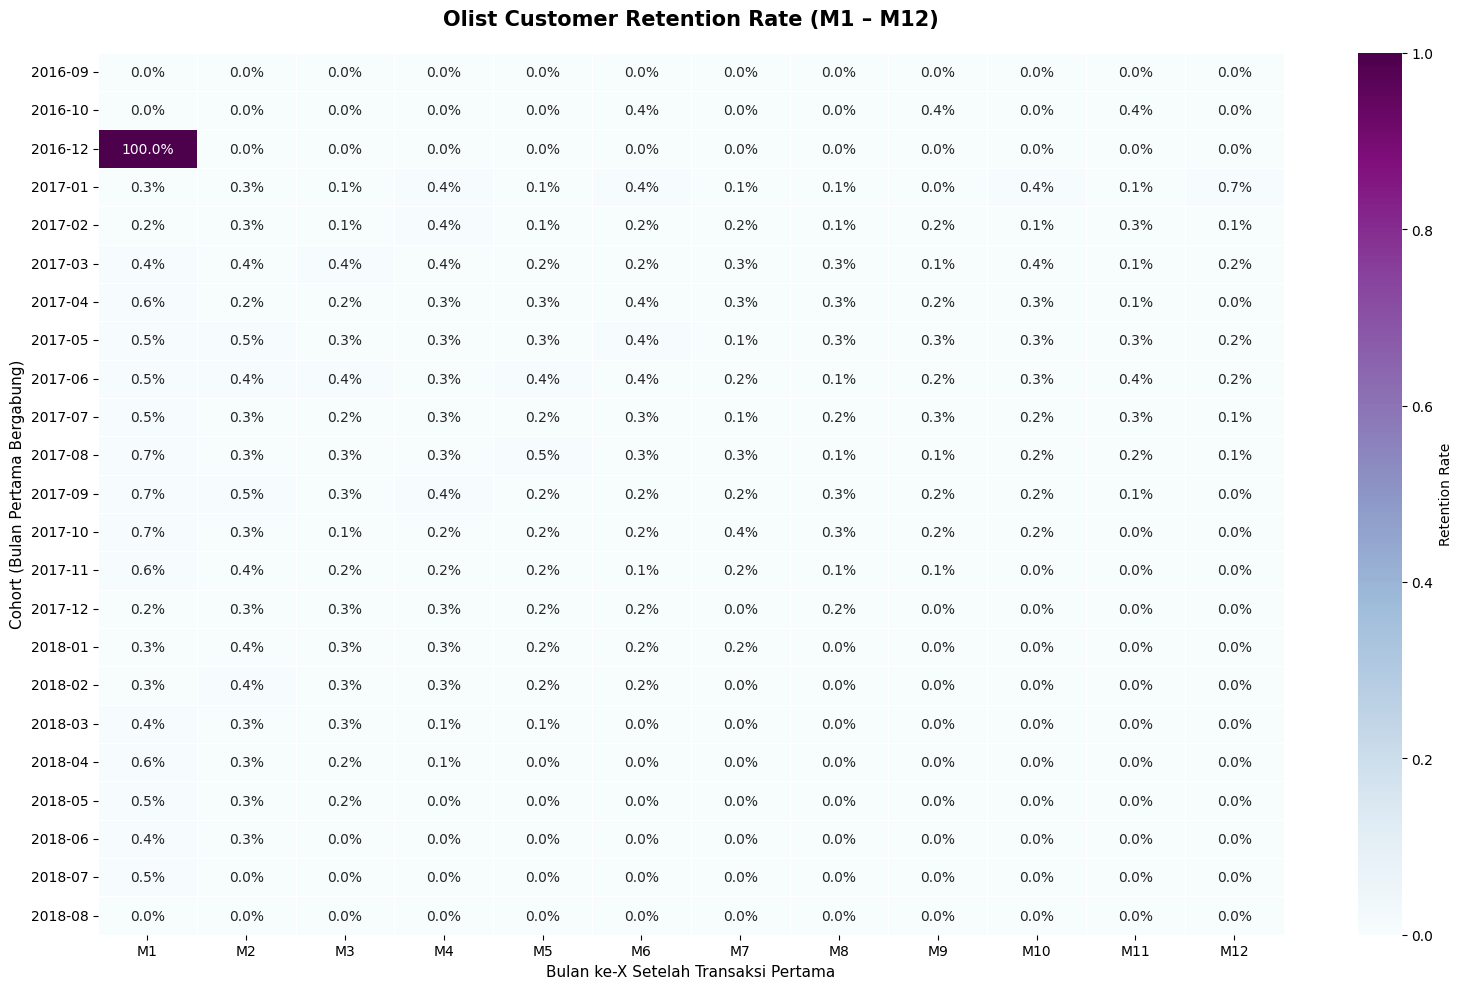

Heatmap disimpan ke 'cohort_retention_heatmap.png'


In [52]:
import matplotlib.pyplot as plt
import seaborn as sns

# Konversi ke persentase relatif terhadap M0
cohort_pivot = df_cohort.set_index('cohort_month')
cohort_percentage = cohort_pivot.divide(cohort_pivot['M0'], axis=0)

# Drop M0 dari visualisasi agar gradasi warna M1–M12 terbaca dengan kontras
cohort_visual = cohort_percentage.drop(columns=['M0'])

plt.figure(figsize=(16, 10))
plt.title('Olist Customer Retention Rate (M1 – M12)', fontsize=15, fontweight='bold', pad=20)

sns.heatmap(
    data=cohort_visual,
    annot=True,
    fmt='.1%',
    cmap='BuPu',
    linewidths=0.5,
    cbar_kws={'label': 'Retention Rate'}
)

plt.ylabel('Cohort (Bulan Pertama Bergabung)', fontsize=11)
plt.xlabel('Bulan ke-X Setelah Transaksi Pertama', fontsize=11)
plt.tight_layout()
plt.savefig('cohort_retention_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()
print("Heatmap disimpan ke 'cohort_retention_heatmap.png'")

---
## 4. RFM Segmentation

### Mengapa RFM?

Cohort Analysis menjawab *"kapan pelanggan pergi?"*, tapi tidak menjawab *"siapa yang paling berharga sekarang?"*. Di sinilah **RFM** masuk.

RFM mengklasifikasikan setiap pelanggan berdasarkan tiga dimensi:

| Dimensi | Pertanyaan | Interpretasi |
|---|---|---|
| **R** ecency | Kapan terakhir beli? | Semakin kecil hari = semakin aktif |
| **F** requency | Seberapa sering beli? | Semakin tinggi = semakin loyal |
| **M** onetary | Berapa total pengeluaran? | Semakin besar = semakin bernilai |

Setiap pelanggan mendapat skor 1–5 di masing-masing dimensi, lalu dikombinasikan menjadi **segmen strategis**.

In [53]:
# Masukkan order_items ke database
order_items.to_sql('order_items_clean', conn, if_exists='replace', index=False)
print("Tabel 'order_items_clean' siap.")

# Preview top 10 pelanggan berdasarkan RFM mentah
query_rfm_preview = """
WITH rfm_basic AS (
    SELECT
        o.customer_unique_id,
        MAX(o.order_purchase_timestamp) AS last_transaction,
        COUNT(DISTINCT o.order_id)      AS frequency,
        SUM(i.price)                    AS monetary
    FROM orders_clean o
    JOIN order_items_clean i ON o.order_id = i.order_id
    GROUP BY o.customer_unique_id
),
max_date_cte AS (
    SELECT MAX(order_purchase_timestamp) AS max_date FROM orders_clean
)
SELECT
    r.customer_unique_id,
    CAST(JULIANDAY((SELECT max_date FROM max_date_cte)) - JULIANDAY(r.last_transaction) AS INT) AS recency_days,
    r.frequency,
    ROUND(r.monetary, 2) AS monetary_brl
FROM rfm_basic r
ORDER BY frequency DESC, monetary_brl DESC
LIMIT 10;
"""

df_rfm_preview = pd.read_sql_query(query_rfm_preview, conn)
df_rfm_preview

Tabel 'order_items_clean' siap.


,customer_unique_id,recency_days,frequency,monetary_brl
0,8d50f5eadf50201ccdcedfb9e2ac8455,8,15,714.63
1,3e43e6105506432c953e165fb2acf44c,182,9,1000.85
2,1b6c7548a2a1f9037c1fd3ddfed95f33,196,7,809.21
3,ca77025e7201e3b30c44b472ff346268,89,7,806.61
4,6469f99c1f9dfae7733b25662e7f1782,62,7,664.20
5,47c1a3033b8b77b3ab6e109eb4d5fdf3,216,6,836.60
6,dc813062e0fc23409cd255f7f53c7074,6,6,687.76
7,63cfc61cee11cbe306bff5857d00bfe4,92,6,579.81
8,f0e310a6839dce9de1638e0fe5ab282a,146,6,438.09
9,12f5d6e1cbf93dafd9dcc19095df0b3d,600,6,58.40


In [54]:
# Ambil seluruh data RFM
query_rfm_all = """
WITH rfm_basic AS (
    SELECT
        o.customer_unique_id,
        MAX(o.order_purchase_timestamp) AS last_transaction,
        COUNT(DISTINCT o.order_id)      AS frequency,
        SUM(i.price)                    AS monetary
    FROM orders_clean o
    JOIN order_items_clean i ON o.order_id = i.order_id
    GROUP BY o.customer_unique_id
),
max_date_cte AS (
    SELECT MAX(order_purchase_timestamp) AS max_date FROM orders_clean
)
SELECT
    r.customer_unique_id,
    CAST(JULIANDAY((SELECT max_date FROM max_date_cte)) - JULIANDAY(r.last_transaction) AS INT) AS recency,
    r.frequency,
    ROUND(r.monetary, 2) AS monetary
FROM rfm_basic r;
"""
df_rfm = pd.read_sql_query(query_rfm_all, conn)

# Scoring R dan M dengan quintile (1–5)
df_rfm['R_score'] = pd.qcut(df_rfm['recency'],  q=5, labels=[5, 4, 3, 2, 1])
df_rfm['M_score'] = pd.qcut(df_rfm['monetary'], q=5, labels=[1, 2, 3, 4, 5])

# F_score manual karena distribusi sangat skewed ke 1 (mayoritas one-time buyer)
df_rfm['F_score'] = df_rfm['frequency'].apply(lambda x: 1 if x == 1 else (3 if x == 2 else 5))

# Segmentasi
def tentukan_segmen(row):
    r, f = int(row['R_score']), int(row['F_score'])
    if r >= 4 and f >= 3:   return 'Champions / Loyal'
    elif r <= 2 and f <= 2: return 'Lost Customers'
    elif r <= 2 and f >= 3: return "Can't Lose Them"
    elif r >= 4 and f <= 2: return 'New Customers'
    else:                   return 'About to Sleep'

df_rfm['Segment'] = df_rfm.apply(tentukan_segmen, axis=1)

print("--- DISTRIBUSI SEGMEN PELANGGAN ---")
print(df_rfm['Segment'].value_counts())
print(f"\nTotal pelanggan teranalisis: {len(df_rfm):,}")

--- DISTRIBUSI SEGMEN PELANGGAN ---
Segment
Lost Customers       36228
New Customers        36224
About to Sleep       18709
Champions / Loyal     1209
Can't Lose Them        988
Name: count, dtype: int64

Total pelanggan teranalisis: 93,358


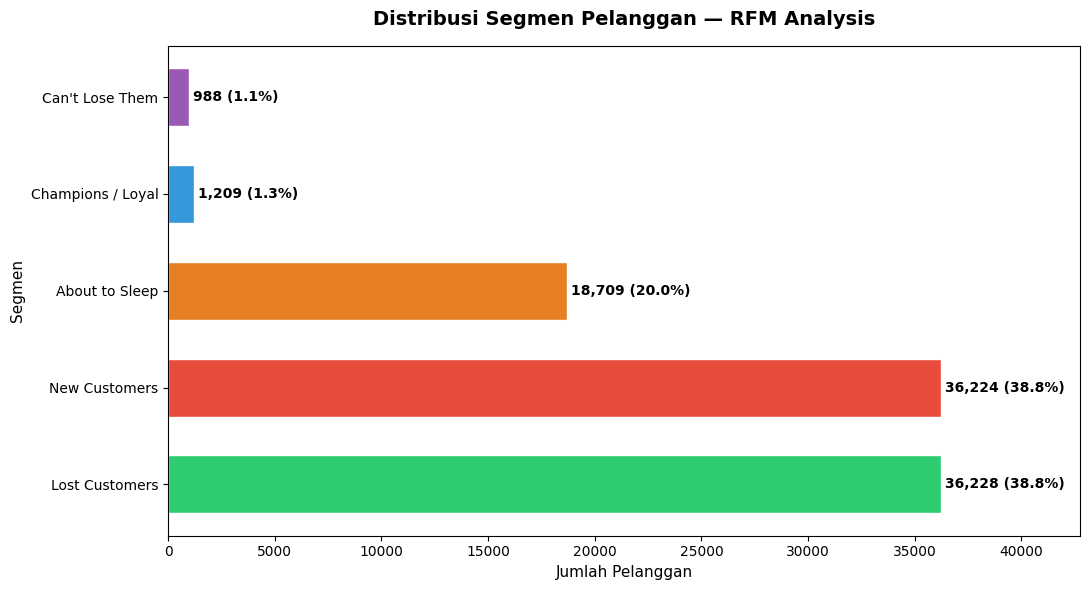

Chart disimpan ke 'rfm_segment_distribution.png'


In [55]:
# Visualisasi distribusi segmen
plt.figure(figsize=(11, 6))
segmen_counts = df_rfm['Segment'].value_counts()

colors = ['#2ecc71', '#e74c3c', '#e67e22', '#3498db', '#9b59b6']
bars = plt.barh(segmen_counts.index, segmen_counts.values, color=colors, edgecolor='white', height=0.6)

plt.title('Distribusi Segmen Pelanggan — RFM Analysis', fontsize=14, fontweight='bold', pad=15)
plt.xlabel('Jumlah Pelanggan', fontsize=11)
plt.ylabel('Segmen', fontsize=11)

for bar, val in zip(bars, segmen_counts.values):
    plt.text(val + 200, bar.get_y() + bar.get_height()/2,
             f'{val:,} ({val/len(df_rfm)*100:.1f}%)',
             va='center', fontweight='bold', fontsize=10)

plt.xlim(0, segmen_counts.max() * 1.18)
plt.tight_layout()
plt.savefig('rfm_segment_distribution.png', dpi=150, bbox_inches='tight')
plt.show()
print("Chart disimpan ke 'rfm_segment_distribution.png'")

In [56]:
# Ringkasan statistik per segmen (rata-rata RFM per kelompok)
rfm_summary = df_rfm.groupby('Segment').agg(
    jumlah_pelanggan=('customer_unique_id', 'count'),
    avg_recency_days=('recency', 'mean'),
    avg_frequency=('frequency', 'mean'),
    avg_monetary_brl=('monetary', 'mean')
).round(1).sort_values('jumlah_pelanggan', ascending=False)

print("--- PROFIL RATA-RATA PER SEGMEN ---")
rfm_summary

--- PROFIL RATA-RATA PER SEGMEN ---


,jumlah_pelanggan,avg_recency_days,avg_frequency,avg_monetary_brl
Segment,,,,
Lost Customers,36228,394.3,1.0,139.7
New Customers,36224,89.6,1.0,140.3
About to Sleep,18709,219.4,1.0,134.1
Champions / Loyal,1209,88.2,2.2,270.2
Can't Lose Them,988,381.3,2.1,246.5


---
## 5. Business Recommendation

### Temuan Utama

**Temuan 1 — Krisis Retensi yang Akut**

Heatmap cohort membuktikan bahwa retensi Olist runtuh di bulan pertama (M1) dengan rata-rata di bawah 2%. Artinya, dari setiap 100 pelanggan yang bergabung di bulan tertentu, kurang dari 2 orang kembali berbelanja bulan berikutnya. Platform ini bertahan bukan karena loyalitas pelanggan, melainkan karena volume akuisisi baru yang terus-menerus — sebuah model yang mahal dan tidak berkelanjutan.

**Temuan 2 — Dominasi Segmen Pasif**

Segmen *Lost Customers* (~36.000 user) hampir identik jumlahnya dengan *New Customers* (~36.000 user). Ini sinyal bahwa Olist kehilangan pelanggan dengan kecepatan yang sama seperti mendapatkan yang baru. *Net retention* mendekati nol.

**Temuan 3 — Potensi Tersembunyi di Segmen Champions**

Meskipun hanya ~1.200 pelanggan, segmen *Champions / Loyal* adalah aset paling berharga. Rata-rata monetary mereka jauh di atas segmen lain. Kehilangan satu Champions setara kehilangan puluhan New Customers dari sisi revenue.

---

### Rekomendasi Aksi Strategis

#### Prioritas 1 — Konversi New Customers sebelum menjadi Lost (Dampak tertinggi)

*New Customers* adalah kelompok yang paling mungkin dikonversi karena pengalaman mereka masih segar. Window of opportunity-nya sempit: maksimal 14–30 hari setelah *delivered*.

**Aksi konkret:**
- Aktifkan *automated email trigger* 7 hari setelah status order `delivered`, berisi kupon diskon 10–15% untuk pembelian berikutnya.
- Personalisasi berdasarkan kategori produk yang sudah dibeli (cross-sell, bukan random).
- **Estimasi impact:** Jika 10% dari ~36.000 *New Customers* berhasil dikonversi dengan rata-rata monetary BRL 150, potensi tambahan revenue adalah **BRL 540.000 per siklus** tanpa biaya akuisisi tambahan.

#### Prioritas 2 — Reaktivasi About to Sleep (Dampak menengah, risiko rendah)

Segmen ini masih "hangat" — mereka pernah beli lebih dari sekali tapi mulai menjauh. Jauh lebih mudah dan murah dikonversi ulang dibanding *Lost Customers*.

**Aksi konkret:**
- Kirim kampanye *win-back* berbasis kategori: tampilkan produk tren terbaru di kategori yang pernah mereka beli sebelumnya.
- Tawarkan *free shipping* tanpa minimum order sebagai insentif tambahan (bukan diskon harga, agar tidak merusak persepsi harga).
- Eksekusi sebelum mereka benar-benar masuk ke bucket *Lost*.

#### Prioritas 3 — Proteksi Champions (Dampak tinggi, volume kecil)

1.200 pelanggan ini adalah tulang punggung revenue per kepala. Biaya kehilangan satu orang dari sini tidak sebanding dengan biaya mempertahankannya.

**Aksi konkret:**
- Masukkan ke program VIP dengan benefit nyata: *free shipping* tanpa syarat, akses early sale, dan prioritas customer service.
- Jangan perlakukan mereka seperti pelanggan biasa — hindari komunikasi massal yang terasa generik.
- Monitor bulanan: jika R_score seorang Champions turun ke 3, segera trigger kampanye retensi personal.

---

### Ringkasan Prioritas Eksekusi

| Segmen | Aksi | Timeline | Estimasi Impact |
|---|---|---|---|
| New Customers | Email trigger + kupon D+7 | Minggu 1–2 | +BRL 540k/siklus (asumsi konversi 10%) |
| About to Sleep | Win-back campaign berbasis kategori | Minggu 2–4 | Cegah migrasi ke Lost |
| Champions | Program VIP + monitoring bulanan | Ongoing | Jaga revenue per kepala tertinggi |
| Lost Customers | Low-priority: kampanye reaktivasi hemat biaya | Kuartal berikutnya | ROI rendah, tapi skala besar |

In [57]:
# Export hasil RFM ke CSV
df_rfm.to_csv('olist_rfm_segments.csv', index=False)
print(f"File 'olist_rfm_segments.csv' disimpan — {len(df_rfm):,} baris.")
print("\nFile output proyek ini:")
print("  - cohort_retention_heatmap.png")
print("  - rfm_segment_distribution.png")
print("  - olist_rfm_segments.csv")

File 'olist_rfm_segments.csv' disimpan — 93,358 baris.

File output proyek ini:
  - cohort_retention_heatmap.png
  - rfm_segment_distribution.png
  - olist_rfm_segments.csv
